# VGGT 3D Reconstruction Walkthrough

This notebook recreates the 3D reconstruction steps used by `demo_viser.py` on the capture stored at `./dataset/astera_office_2/images/`. Each section exposes an intermediate prediction so you can inspect how VGGT builds cameras, depth, and point clouds.

## 0. Imports and runtime setup
Make sure the VGGT environment is activated before executing the cells.

In [18]:
%matplotlib inline

import os
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from vggt.models.vggt import VGGT
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri
from vggt.utils.geometry import unproject_depth_map_to_point_map, closed_form_inverse_se3


In [19]:
IMAGE_FOLDER = Path("../dataset/astera_office_2/images/")
assert IMAGE_FOLDER.exists(), f"Image folder not found: {IMAGE_FOLDER}"

image_paths = sorted(
    p for p in IMAGE_FOLDER.iterdir()
    if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
)

MAX_IMAGES = None  # set to an integer to limit the sequence if memory becomes an issue
if MAX_IMAGES is not None:
    image_paths = image_paths[:MAX_IMAGES]

print(f"Found {len(image_paths)} images")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if device.type == "cuda" and torch.cuda.get_device_capability()[0] >= 8 else torch.float16
print(f"Using device: {device}, autocast dtype: {dtype}")


Found 41 images
Using device: cuda, autocast dtype: torch.bfloat16


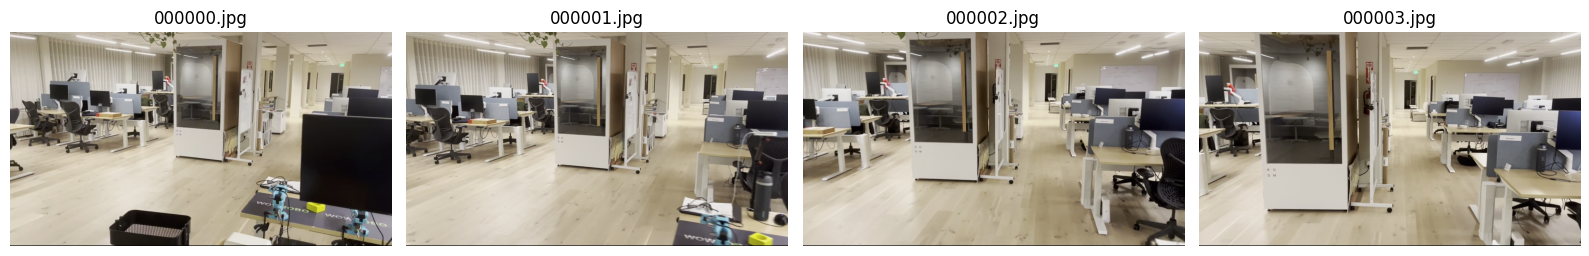

In [3]:
num_preview = min(4, len(image_paths))
if num_preview > 0:
    fig, axes = plt.subplots(1, num_preview, figsize=(4 * num_preview, 4))
    if num_preview == 1:
        axes = [axes]
    for ax, path in zip(axes, image_paths[:num_preview]):
        ax.imshow(Image.open(path))
        ax.set_title(path.name)
        ax.axis("off")
    plt.tight_layout()
else:
    raise RuntimeError("No images found for reconstruction.")


## 1. Load and preprocess images
This step mirrors `load_and_preprocess_images` from the demo script.


In [4]:
images_tensor = load_and_preprocess_images([str(p) for p in image_paths])
print(f"Preprocessed tensor shape: {images_tensor.shape}")
images_tensor = images_tensor.to(device)

Preprocessed tensor shape: torch.Size([41, 3, 294, 518])


## 2. Instantiate VGGT and load weights
Weights are fetched from the public Hugging Face checkpoint the first time you run this cell.

In [5]:
# model = VGGT()
# state_dict = torch.hub.load_state_dict_from_url("https://huggingface.co/facebook/VGGT-1B/resolve/main/model.pt", progress=True, map_location="cpu")
# model.load_state_dict(state_dict)
# model = model.to(device)
# model.eval()
# print("Model ready for inference.")
model = VGGT.from_pretrained("facebook/VGGT-1B").to(device)
model.eval();


## 3. Aggregate image tokens
VGGT first converts the image sequence into transformer tokens via the aggregator module.

In [6]:
with torch.no_grad():
    batched_images = images_tensor.unsqueeze(0)  # add batch dimension
    autocast_ctx = torch.cuda.amp.autocast(dtype=dtype) if device.type == "cuda" else nullcontext()
    with autocast_ctx:
        aggregated_tokens_list, patch_start_idx = model.aggregator(batched_images)

print(f"Number of refinement iterations: {len(aggregated_tokens_list)}")
print("Token shapes:", [t.shape for t in aggregated_tokens_list])
print(f"Patch start index: {patch_start_idx}")


/tmp/ipykernel_542348/224317872.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = torch.cuda.amp.autocast(dtype=dtype) if device.type == "cuda" else nullcontext()


Number of refinement iterations: 24
Token shapes: [torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048]), torch.Size([1, 41, 782, 2048])]
Patch start index: 5


## 4. Predict cameras, depth, points, and tracks
Using the aggregated tokens we replicate the per-head calls from the demo script.

In [7]:
with torch.no_grad():
    # Camera poses
    pose_enc_list = model.camera_head(aggregated_tokens_list)
    pose_enc = pose_enc_list[-1]
    extrinsic, intrinsic = pose_encoding_to_extri_intri(pose_enc, batched_images.shape[-2:])

    # Dense depth and point predictions
    depth_map, depth_conf = model.depth_head(aggregated_tokens_list, batched_images, patch_start_idx)
    point_map, point_conf = model.point_head(aggregated_tokens_list, batched_images, patch_start_idx)

    # Example point tracking query
    query_points = torch.tensor([[100.0, 200.0], [60.72, 259.94]], device=device)
    track_list, vis_score, conf_score = model.track_head(
        aggregated_tokens_list, batched_images, patch_start_idx, query_points=query_points[None]
    )

print(f"Pose encoding shape: {pose_enc.shape}")
print(f"Extrinsic shape: {extrinsic.shape}, Intrinsic shape: {intrinsic.shape}")
print(f"Depth map shape: {depth_map.shape}, depth confidence shape: {depth_conf.shape}")
print(f"Point map shape: {point_map.shape}, point confidence shape: {point_conf.shape}")
print(f"Track list length: {len(track_list)}, track tensor shape: {track_list[-1].shape}")


Pose encoding shape: torch.Size([1, 41, 9])
Extrinsic shape: torch.Size([1, 41, 3, 4]), Intrinsic shape: torch.Size([1, 41, 3, 3])
Depth map shape: torch.Size([1, 41, 294, 518, 1]), depth confidence shape: torch.Size([1, 41, 294, 518])
Point map shape: torch.Size([1, 41, 294, 518, 3]), point confidence shape: torch.Size([1, 41, 294, 518])
Track list length: 4, track tensor shape: torch.Size([1, 41, 2, 2])


## 5. Convert depth to 3D points via camera geometry
Unprojecting the depth maps often yields cleaner 3D geometry than the point-map head.

In [8]:
point_map_by_unprojection = unproject_depth_map_to_point_map(
    depth_map.squeeze(0), extrinsic.squeeze(0), intrinsic.squeeze(0)
)
print(f"Unprojected point map shape: {point_map_by_unprojection.shape}")


Unprojected point map shape: (41, 294, 518, 3)


## 6. Visualize intermediate predictions

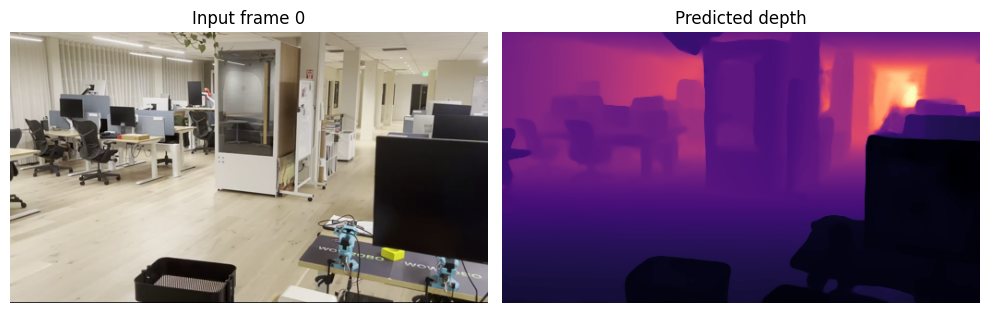

In [9]:
frame_idx = 0  # change to visualize a different frame

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(images_tensor[frame_idx].detach().cpu().permute(1, 2, 0))
axs[0].set_title(f"Input frame {frame_idx}")
axs[0].axis("off")

depth_vis = depth_map[0, frame_idx].detach().cpu().squeeze().numpy()
axs[1].imshow(depth_vis, cmap="magma")
axs[1].set_title("Predicted depth")
axs[1].axis("off")
plt.tight_layout()


In [10]:
import open3d as o3d

sample_frame = 1
points = point_map_by_unprojection[sample_frame].reshape(-1, 3)
colors = images_tensor[sample_frame].detach().cpu().permute(1, 2, 0).reshape(-1, 3).numpy()

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize
print(f"Visualizing {len(pcd.points)} points")
o3d.visualization.draw_geometries(
    [pcd],
    window_name="3D Point Cloud (World Coordinates)",
    width=1024,
    height=768,
    left=50,
    top=50,
    point_show_normal=False
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Visualizing 152292 points


In [21]:
import open3d as o3d

# Combine all frames into one point cloud
all_points = []
all_colors = []

for frame_idx in range(len(images_tensor)):
    points = point_map_by_unprojection[frame_idx].reshape(-1, 3)
    colors = images_tensor[frame_idx].detach().cpu().permute(1, 2, 0).reshape(-1, 3).numpy()
    all_points.append(points)
    all_colors.append(colors)

all_points = np.vstack(all_points)
all_colors = np.vstack(all_colors)

# Create and visualize combined point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(all_points)
pcd.colors = o3d.utility.Vector3dVector(all_colors)

print(f"Visualizing {len(pcd.points)} points from {len(images_tensor)} frames")
o3d.visualization.draw_geometries(
    [pcd],
    window_name="Full Scene Reconstruction (All Frames)",
    width=1024,
    height=768,
    left=50,
    top=50,
    point_show_normal=False
)

Visualizing 6243972 points from 41 frames


In [11]:
# Combine all frames with confidence filtering (matching demo_viser.py behavior)
all_points = []
all_colors = []
all_conf = []

for frame_idx in range(len(images_tensor)):
    points = point_map_by_unprojection[frame_idx].reshape(-1, 3)
    colors = images_tensor[frame_idx].detach().cpu().permute(1, 2, 0).reshape(-1, 3).numpy()
    conf = depth_conf[0, frame_idx].detach().cpu().numpy().reshape(-1)
    
    all_points.append(points)
    all_colors.append(colors)
    all_conf.append(conf)

# Flatten all frames
points_flat = np.vstack(all_points)
colors_flat = np.vstack(all_colors)
conf_flat = np.concatenate(all_conf)

# Filter by confidence (matching demo_viser.py logic)
percentile = 25.0  # Default --conf_threshold, adjust to remove more/less noise
cutoff = np.percentile(conf_flat, percentile)
valid = (conf_flat >= cutoff) & (conf_flat > 1e-5)

print(f"Confidence cutoff at {percentile}th percentile: {cutoff:.6f}")
print(f"Keeping {valid.sum():,} / {len(valid):,} points ({100 * valid.sum() / len(valid):.1f}%)")

# Filter points and colors
points_filtered = points_flat[valid]
colors_filtered = colors_flat[valid]

# Optional: center the point cloud like demo_viser.py
points_centered = points_filtered - points_filtered.mean(axis=0)

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_centered)  # Use points_filtered if you don't want centering
pcd.colors = o3d.utility.Vector3dVector(colors_filtered)

# Optional: statistical outlier removal for even cleaner results
pcd, outlier_mask = pcd.remove_statistical_outlier(nb_neighbors=30, std_ratio=1.0)
print(f"After outlier removal: {len(pcd.points):,} points")

# Visualize
print(f"Visualizing filtered point cloud from {len(images_tensor)} frames")
o3d.visualization.draw_geometries(
    [pcd],
    window_name="Filtered Scene Reconstruction (All Frames)",
    width=1024,
    height=768,
    left=50,
    top=50,
    point_show_normal=False
)

Confidence cutoff at 25.0th percentile: 1.000803
Keeping 4,682,996 / 6,243,972 points (75.0%)
After outlier removal: 4,149,522 points
Visualizing filtered point cloud from 41 frames


## 7. Visualize camera poses
Overlay the estimated camera frames on an Open3D rendering of the filtered point cloud (OpenCV convention: x→red, y→green, z→blue).

In [12]:
import open3d as o3d
from vggt.utils.geometry import closed_form_inverse_se3

# Confidence-filtered point cloud (match demo_viser percentile filtering)
conf_flat = depth_conf[0].detach().cpu().numpy().reshape(-1)
points_flat = point_map_by_unprojection.reshape(-1, 3)
colors_flat = images_tensor.detach().cpu().permute(0, 2, 3, 1).numpy().reshape(-1, 3)

percentile = 25.0  # drop the lowest-confidence pixels
cutoff = np.percentile(conf_flat, percentile)
valid = (conf_flat >= cutoff) & (conf_flat > 1e-5)

pcd_filtered = o3d.geometry.PointCloud()
pcd_filtered.points = o3d.utility.Vector3dVector(points_flat[valid])
pcd_filtered.colors = o3d.utility.Vector3dVector(colors_flat[valid])

# Rotate scene so that Y becomes up (180° about X to preserve handedness)
world_fix = np.array(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, -1.0, 0.0, 0.0],
        [0.0, 0.0, -1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ],
    dtype=np.float32,
)

pcd_filtered.transform(world_fix)

# Build camera frames in world coordinates
extrinsic_batch = extrinsic.squeeze(0).detach()
S = extrinsic_batch.shape[0]
extrinsic_h = torch.zeros((S, 4, 4), dtype=extrinsic_batch.dtype, device=extrinsic_batch.device)
extrinsic_h[:, :3, :4] = extrinsic_batch
extrinsic_h[:, 3, 3] = 1.0

cam_to_world = closed_form_inverse_se3(extrinsic_h).cpu().numpy()

frame_scale = 0.05  # adjust to match your scene scale
camera_frames = []
for idx, T in enumerate(cam_to_world):
    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_scale)
    frame.transform(world_fix @ T)
    camera_frames.append(frame)

print(f"Filtered points: {len(pcd_filtered.points)} | Cameras: {len(camera_frames)}")

o3d.visualization.draw_geometries(
    [pcd_filtered, *camera_frames],
    window_name="Point cloud with camera poses",
    width=1024,
    height=768,
    left=100,
    top=100,
)


Filtered points: 4682996 | Cameras: 41


## 8. Derive floor normal and top-down projection
Average the camera orientations to estimate the floor normal, rotate the filtered 3D points into that frame, and rasterize a bird's-eye image.

Using 4682996 high-confidence points for top-down density map
Estimated floor normal (world frame): [ 0.01775184 -0.98549014 -0.16880183]


(-0.5, 1023.5, -0.5, 1023.5)

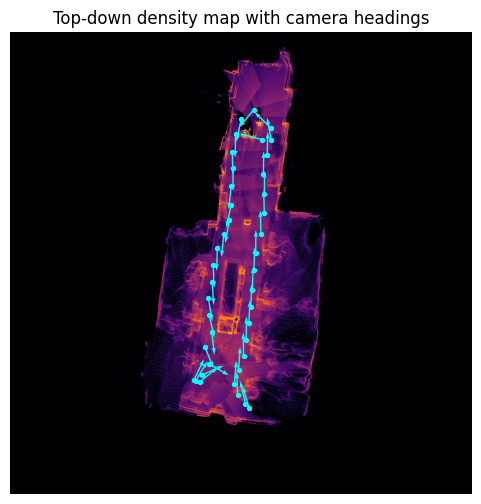

In [29]:
from vggt.utils.geometry import closed_form_inverse_se3

# Confidence-filtered points (match demo_viser percentile filtering)
conf_flat = depth_conf[0].detach().cpu().numpy().reshape(-1)
points_flat = point_map_by_unprojection.reshape(-1, 3)

percentile = 25.0
cutoff = np.percentile(conf_flat, percentile)
valid_mask = (conf_flat >= cutoff) & (conf_flat > 1e-5)
points_valid = points_flat[valid_mask]
print(f"Using {points_valid.shape[0]} high-confidence points for top-down density map")

# Estimate floor normal from camera extrinsics (OpenCV convention: +Y points down)
R_world_to_cam = extrinsic.squeeze(0).detach().cpu().numpy()[:, :3, :3]

down_dirs = R_world_to_cam[:, 1, :].copy()
ref_down = down_dirs[0]
for i in range(len(down_dirs)):
    if np.dot(down_dirs[i], ref_down) < 0:
        down_dirs[i] *= -1
avg_down = down_dirs.mean(axis=0)
floor_normal = -avg_down / np.linalg.norm(avg_down)
print(f"Estimated floor normal (world frame): {floor_normal}")

# Build horizontal basis vectors
x_dirs = R_world_to_cam[:, 0, :].copy()
for i in range(len(x_dirs)):
    if np.dot(x_dirs[i], x_dirs[0]) < 0:
        x_dirs[i] *= -1
x_dirs_proj = x_dirs - (x_dirs @ floor_normal)[:, None] * floor_normal
basis_x = x_dirs_proj.mean(axis=0)
basis_x /= np.linalg.norm(basis_x)

basis_y = np.cross(floor_normal, basis_x)
basis_y /= np.linalg.norm(basis_y)

basis = np.stack([basis_x, basis_y, floor_normal], axis=0)

# Project points into the floor-aligned frame
scene_center = points_valid.mean(axis=0)
coords = (points_valid - scene_center) @ basis.T
coords_xy = coords[:, :2]

# Normalise to a square canvas and accumulate density
extent = np.abs(coords_xy).max()
if extent < 1e-6:
    raise RuntimeError("Degenerate extent for top-down projection")
margin = 1.05
coords_norm = coords_xy / (extent * margin)

resolution = 1024
uv = ((coords_norm + 1.0) * 0.5 * (resolution - 1)).astype(int)
uv = np.clip(uv, 0, resolution - 1)
rows, cols = uv[:, 1], uv[:, 0]

density = np.zeros((resolution, resolution), dtype=np.int32)
np.add.at(density, (rows, cols), 1)

density_vis = np.log1p(density)

# Camera positions and headings in floor frame
extrinsic_batch = extrinsic.squeeze(0).detach()
S = extrinsic_batch.shape[0]
extrinsic_h = torch.zeros((S, 4, 4), dtype=extrinsic_batch.dtype, device=extrinsic_batch.device)
extrinsic_h[:, :3, :4] = extrinsic_batch
extrinsic_h[:, 3, 3] = 1.0
cam_to_world = closed_form_inverse_se3(extrinsic_h).cpu().numpy()

cam_positions = cam_to_world[:, :3, 3]
cam_coords = (cam_positions - scene_center) @ basis.T
cam_norm = cam_coords[:, :2] / (extent * margin)
cam_pix = (cam_norm + 1.0) * 0.5 * (resolution - 1)

forward_vectors = cam_to_world[:, :3, 2]
forward_coords = forward_vectors @ basis.T
forward_xy = forward_coords[:, :2]
forward_norm = np.linalg.norm(forward_xy, axis=1, keepdims=True)
forward_norm[forward_norm < 1e-6] = 1.0
forward_xy_unit = forward_xy / forward_norm
arrow_len = resolution * 0.05
arrow_vec = forward_xy_unit * arrow_len

plt.figure(figsize=(6, 6))
plt.imshow(density_vis, cmap='inferno', origin='lower')
plt.scatter(cam_pix[:, 0], cam_pix[:, 1], c='cyan', s=8, label='Camera centers')
plt.quiver(
    cam_pix[:, 0],
    cam_pix[:, 1],
    arrow_vec[:, 0],
    arrow_vec[:, 1],
    angles='xy',
    scale_units='xy',
    scale=1.0,
    color='cyan',
    width=0.003,
)
plt.title('Top-down density map with camera headings')
plt.axis('off')


## 9. Package outputs for downstream use
Wrap the tensors in a dictionary similar to the demo for reuse.

In [ ]:
predictions = {
    "images": batched_images.squeeze(0).detach().cpu(),
    "pose_enc": pose_enc.detach().cpu(),
    "extrinsic": extrinsic.detach().cpu(),
    "intrinsic": intrinsic.detach().cpu(),
    "depth": depth_map.detach().cpu(),
    "depth_conf": depth_conf.detach().cpu(),
    "world_points": point_map.detach().cpu(),
    "world_points_conf": point_conf.detach().cpu(),
    "track": track_list[-1].detach().cpu(),
    "vis": vis_score.detach().cpu(),
    "conf": conf_score.detach().cpu(),
    "world_points_from_depth": point_map_by_unprojection,
}

for key, value in predictions.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: {value.shape} ({value.dtype})")
    else:
        print(f"{key}: numpy array with shape {value.shape} and dtype {value.dtype}")


images: torch.Size([41, 3, 294, 518]) (torch.float32)
pose_enc: torch.Size([1, 41, 9]) (torch.float32)
extrinsic: torch.Size([1, 41, 3, 4]) (torch.float32)
intrinsic: torch.Size([1, 41, 3, 3]) (torch.float32)
depth: torch.Size([1, 41, 294, 518, 1]) (torch.float32)
depth_conf: torch.Size([1, 41, 294, 518]) (torch.float32)
world_points: torch.Size([1, 41, 294, 518, 3]) (torch.float32)
world_points_conf: torch.Size([1, 41, 294, 518]) (torch.float32)
track: torch.Size([1, 41, 2, 2]) (torch.float32)
vis: torch.Size([1, 41, 2]) (torch.float32)
conf: torch.Size([1, 41, 2]) (torch.float32)
world_points_from_depth: numpy array with shape (41, 294, 518, 3) and dtype float64


## 10. Output tensor glossary
The table below summarises each tensor returned in `predictions`, its shape convention (batch `B`, frames `S`, height `H`, width `W`, tracked points `N`), and its semantic meaning:returning to earlier sections if you need more detail.

| Key | Shape | Meaning |
| --- | --- | --- |
| `images` | `(S, 3, H, W)` | Preprocessed RGB inputs in `[0, 1]`, per frame.
| `pose_enc` | `(B, S, 9)` | Camera pose encoding (translation, quaternion, FoV) for each frame.
| `extrinsic` | `(B, S, 3, 4)` | Camera-to-world 3×4 SE(3) matrices (OpenCV cam-from-world convention).
| `intrinsic` | `(B, S, 3, 3)` | Pixel intrinsics with principal point centred at `(W/2, H/2)`.
| `depth` | `(B, S, H, W, 1)` | Predicted metric depth per pixel.
| `depth_conf` | `(B, S, H, W)` | Confidence for each depth value (higher is better).
| `world_points` | `(B, S, H, W, 3)` | 3D points from the point-head branch (camera frame).
| `world_points_conf` | `(B, S, H, W)` | Confidence for each point-head prediction.
| `track` | `(B, S, N, 2)` | 2D pixel locations of user-specified tracked points across frames.
| `vis` | `(B, S, N)` | Visibility scores for the tracked points.
| `conf` | `(B, S, N)` | Confidence scores for the tracked point trajectories.
| `world_points_from_depth` | `(S, H, W, 3)` | Depth-unprojected 3D points (NumPy) in world coordinates.
